In [45]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [46]:
image = cv2.imread(r'C:\Users\Hp\Pictures\OpenCVSamples\car.jpg',0)

# or we could have used cvt.COLOR_BGR2GRAY to convert the image to grayscale.

In [47]:
def show_img(img , title):
    plt.imshow(img , cmap='gray')
    plt.title(title)
    plt.show()

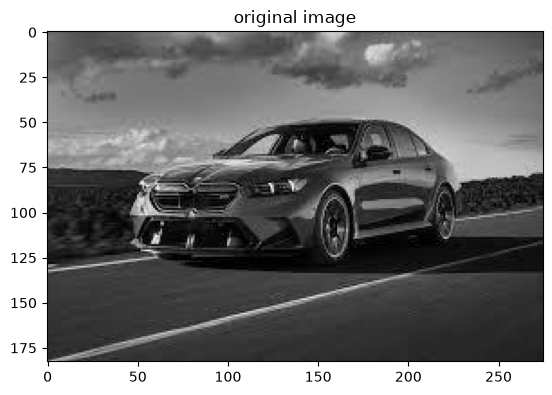

In [48]:
show_img(image , 'original image')

```text
Simple thresholding 
Technique	Description
cv2.THRESH_BINARY	Above threshold -> 255, below -> 0.
cv2.THRESH_BINARY_INV	Above threshold -> 0, below -> 255 (inverse of binary).
cv2.THRESH_TRUNC	Above threshold -> set to threshold, below -> unchanged.
cv2.THRESH_TOZERO	Below threshold -> 0, above -> unchanged.
cv2.THRESH_TOZERO_INV	Above threshold -> 0, below -> unchanged (inverse of TOZERO).

Try Simple Binary Thresholding

The Goal: Turn the image into pure black and white using a single global threshold
.
What to do:
Call OpenCV's cv2.threshold() function
.
Choose a threshold boundary value of 120 and a maximum value of 255
.
Use the cv2.THRESH_BINARY flag
.
Beginner Tip: Remember that cv2.threshold() returns two values. Unpack them as _ , thresh_binary = cv2.threshold(...) so you discard the first return value and keep your output image array
.
What to expect: Pixels above 120 will turn white; pixels below 120 will turn black

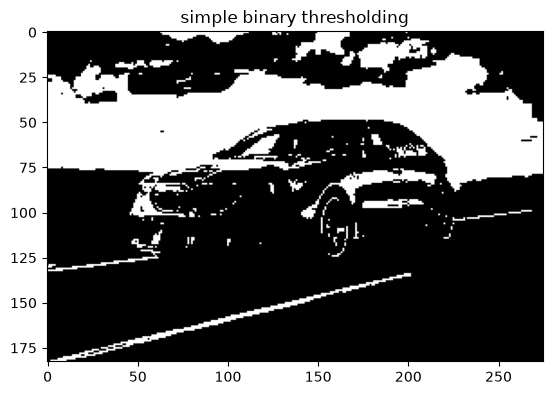

In [49]:
ret,threshbinary = cv2.threshold(image,120,255,cv2.THRESH_BINARY)
show_img(threshbinary , 'simple binary thresholding')

now work with other 4 types of simple thresholding and display the outputs

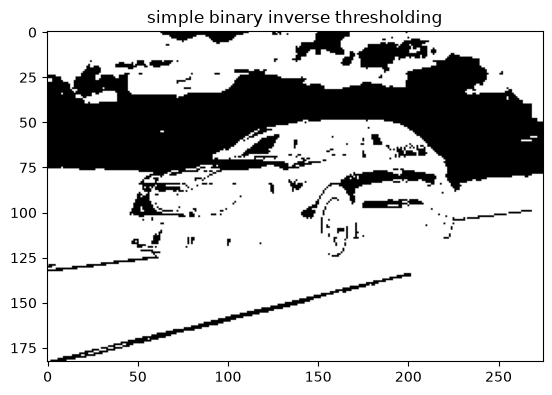

In [50]:
ret,threshbinaryinv = cv2.threshold(image,120,255,cv2.THRESH_BINARY_INV)
show_img(threshbinaryinv , 'simple binary inverse thresholding')

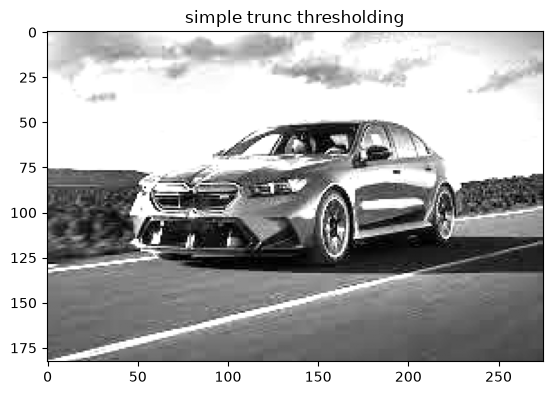

In [51]:
ret,threshtrunc = cv2.threshold(image,120,255,cv2.THRESH_TRUNC)
show_img(threshtrunc , 'simple trunc thresholding')

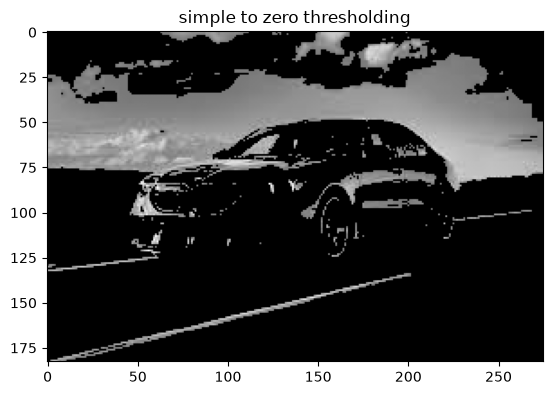

In [52]:
ret,threshtozero = cv2.threshold(image,120,255,cv2.THRESH_TOZERO)
show_img(threshtozero , 'simple to zero thresholding')

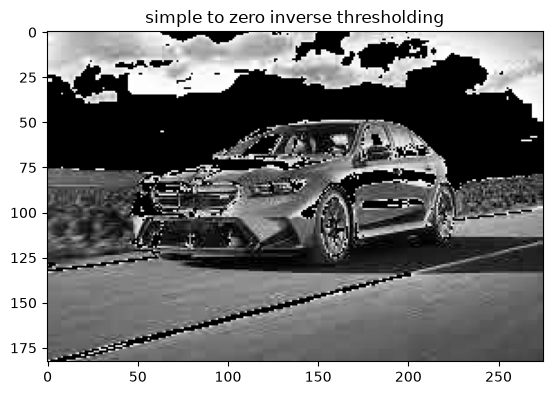

In [53]:
ret,threshtozeroinv = cv2.threshold(image,120,255,cv2.THRESH_TOZERO_INV)
show_img(threshtozeroinv , 'simple to zero inverse thresholding')

Apply Adaptive Mean Thresholding

The Goal: Calculate a unique threshold for small blocks of your image to bypass global lighting and shadow issues
.
What to do:
Call OpenCV's cv2.adaptiveThreshold() function
.
Set the parameters: maxValue = 255, adaptiveMethod = cv2.ADAPTIVE_THRESH_MEAN_C, thresholdType = cv2.THRESH_BINARY
.
Choose a neighborhood blockSize of 199 (this must be an odd integer!) and a constant C of 5
.
What to expect: The threshold for each pixel is calculated as the mathematical average (mean) of its surrounding 199x199 neighborhood, minus 5
. This will extract crisp text boundaries even if a heavy shadow falls across the paper

For ADAPTIVE_THRESH_MEAN_C, OpenCV essentially calculates:

T=local mean−C

cv2.ADAPTIVE_THRESH_MEAN_C

This tells OpenCV:

Calculate the threshold for each pixel using the local mean of its neighborhood.


cv2.THRESH_BINARY

This tells OpenCV how to convert the pixel after finding its local threshold.

It applies:

```text
output=
255 , if pixel>T
0 , if pixel≤T

where T is now the local threshold, rather than one fixed threshold like 120

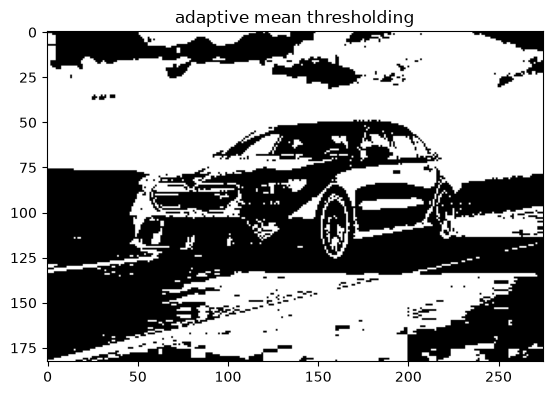

In [54]:
thresh_adaptive_mean = cv2.adaptiveThreshold(
    src=image,
    maxValue=255,
    adaptiveMethod=cv2.ADAPTIVE_THRESH_MEAN_C,
    thresholdType=cv2.THRESH_BINARY,
    blockSize=199,
    C=5
)

show_img(thresh_adaptive_mean , 'adaptive mean thresholding')

Apply Adaptive Gaussian Thresholding

The Goal: Calculate local thresholds using a weighted sum to handle gradual transitions in light more naturally
.
What to do:
Call cv2.adaptiveThreshold() again
.
Change the method parameter to cv2.ADAPTIVE_THRESH_GAUSSIAN_C
.
Keep the block size at 199 and constant C at 5
.
What to expect: This method is often cleaner than the mean calculation in areas with gradual lighting variations
.

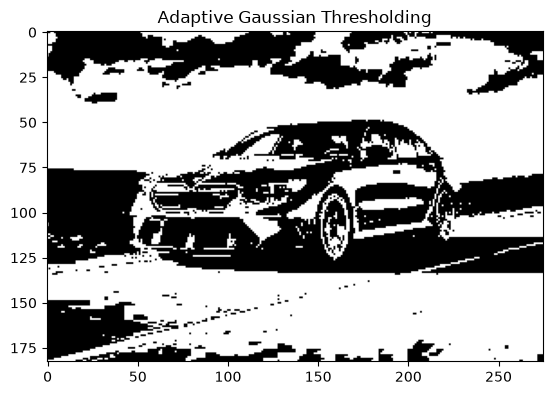

In [57]:
thresh_gauss = cv2.adaptiveThreshold(
    src=image,
    maxValue=255,
    adaptiveMethod=cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    thresholdType=cv2.THRESH_BINARY,
    blockSize=199,
    C=5
)
show_img(thresh_gauss, "Adaptive Gaussian Thresholding")